Install Required Libraries

In [67]:
!pip install pandas numpy matplotlib seaborn

Import Libraries

In [68]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
sns.set(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


Create Project Sections

# Trader Behavior vs Market Sentiment Analysis

## Objective
Analyze the relationship between trader performance and Bitcoin market sentiment (Fear & Greed Index).

## Libraries Used
- Pandas
- NumPy
- Matplotlib
- Seaborn

Upload Files to Google Colab

In [69]:
from google.colab import files
uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index (1).csv
Saving historical_data.csv to historical_data (1).csv


Load the Data Using Pandas

In [70]:
import pandas as pd

# Load datasets
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

# Display first few rows
print("Sentiment Dataset")
display(sentiment.head())

print("Trader Dataset")
display(trades.head())

Sentiment Dataset


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


Trader Dataset


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


Check Dataset Shape

In [71]:
print("Sentiment Dataset Shape:", sentiment.shape)
print("Trader Dataset Shape:", trades.shape)

Sentiment Dataset Shape: (2644, 4)
Trader Dataset Shape: (211224, 16)


Check Column Names

In [72]:
print("Sentiment Columns")
print(sentiment.columns)

print("Trader Data Columns")
print(trades.columns)

Sentiment Columns
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Trader Data Columns
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


Check Missing Values

In [73]:
print("Missing Values in Sentiment Data")
print(sentiment.isnull().sum())

print("Missing Values in Trader Data")
print(trades.isnull().sum())

Missing Values in Sentiment Data
timestamp         0
value             0
classification    0
date              0
dtype: int64
Missing Values in Trader Data
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


Dataset Information

In [74]:
sentiment.info()
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-nu

## Data Cleaning and Preprocessing

Convert Date Columns

In [75]:
# Convert date columns to datetime format

sentiment['date'] = pd.to_datetime(sentiment['date'])
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')

print("Date columns converted successfully")

Date columns converted successfully


Extract Date from Trader Timestamp

In [76]:
# Extract date from trader timestamp

trades['Date'] = trades['Timestamp IST'].dt.date
sentiment['Date'] = sentiment['date'].dt.date

print("Date extracted from timestamp")

Date extracted from timestamp


Check Data Again

In [77]:
print(trades.head())
print(sentiment.head())


                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0

Remove Missing Sentiment Values

In [78]:
sentiment = sentiment.dropna()

print("Missing sentiment values removed")

Missing sentiment values removed


Check Actual Column Names

In [79]:
print(trades.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date'],
      dtype='object')


In [80]:
# Remove extra spaces from column names
trades.columns = trades.columns.str.strip()
sentiment.columns = sentiment.columns.str.strip()

print(trades.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date'],
      dtype='object')


In [81]:
for col in trades.columns:
    print(col)

Account
Coin
Execution Price
Size Tokens
Size USD
Side
Timestamp IST
Start Position
Direction
Closed PnL
Transaction Hash
Order ID
Crossed
Fee
Trade ID
Timestamp
Date


Convert numeric columns

In [82]:
# Convert numeric columns

trades['Closed PnL'] = pd.to_numeric(trades['Closed PnL'], errors='coerce')

print("Numeric conversion completed")

Numeric conversion completed


Check Sentiment Dataset Columns

In [83]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date', 'Date'], dtype='object')


Ensure Date Columns Match

In [84]:
trades['Date'] = pd.to_datetime(trades['Date'])
sentiment['Date'] = pd.to_datetime(sentiment['Date'])

print("Date format verified")

Date format verified


Merge the Datasets

In [85]:
merged_data = pd.merge(trades, sentiment, on="Date", how="left")

print("Datasets merged successfully")

Datasets merged successfully


Check Merged Dataset

In [86]:
print(merged_data.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed PnL  ...     Order ID  Crossed       Fee      Trade ID  \
0         0.0  ...  5201

Check Missing Sentiment Values

In [87]:
print(merged_data['classification'].isnull().sum())

6


In [88]:
merged_data = merged_data.dropna(subset=['classification'])

Confirm Final Dataset

In [89]:
print(merged_data.shape)

(211218, 21)


Average Profit by Market Sentiment


Do traders earn more during Fear or Greed?

In [90]:
profit_by_sentiment = merged_data.groupby('classification')['Closed PnL'].mean()

print(profit_by_sentiment)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


Total Profit by Sentiment

In [91]:
total_profit = merged_data.groupby('classification')['Closed PnL'].sum()

print(total_profit)

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64


Number of Trades by Sentiment

In [92]:
trade_count = merged_data.groupby('classification').size()

print(trade_count)

classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


Buy vs Sell Behavior

In [93]:
side_analysis = pd.crosstab(merged_data['Side'], merged_data['classification'])

print(side_analysis)

classification  Extreme Fear  Extreme Greed   Fear  Greed  Neutral
Side                                                              
BUY                    10935          17940  30270  24576    18969
SELL                   10465          22052  31567  25727    18717


Win Rate Analysis

In [94]:
merged_data.loc[:, 'profit'] = merged_data['Closed PnL'] > 0

Now calculate win rate:

In [95]:
win_rate = merged_data.groupby('classification')['profit'].mean()

print(win_rate)

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: profit, dtype: float64


Top Traders

In [96]:
top_traders = merged_data.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False)

print(top_traders.head(10))

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.605395e+05
Name: Closed PnL, dtype: float64


Average Profit vs Sentiment

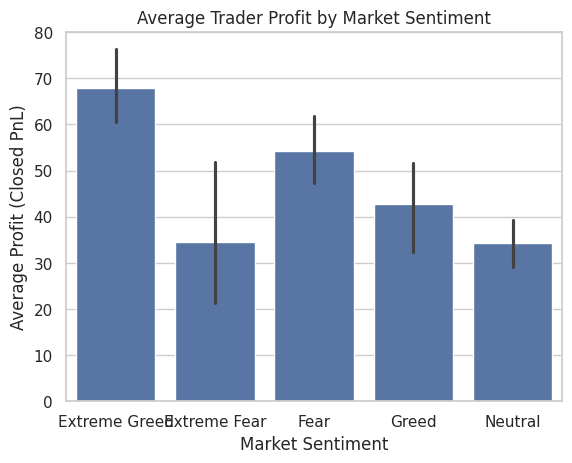

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x='classification', y='Closed PnL', data=merged_data)

plt.title("Average Trader Profit by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Profit (Closed PnL)")
plt.show()

Profit Distribution

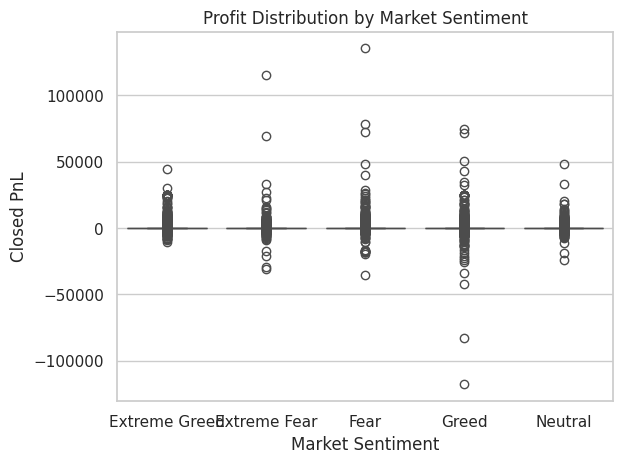

In [98]:
sns.boxplot(x='classification', y='Closed PnL', data=merged_data)

plt.title("Profit Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")
plt.show()

Buy vs Sell Behavior

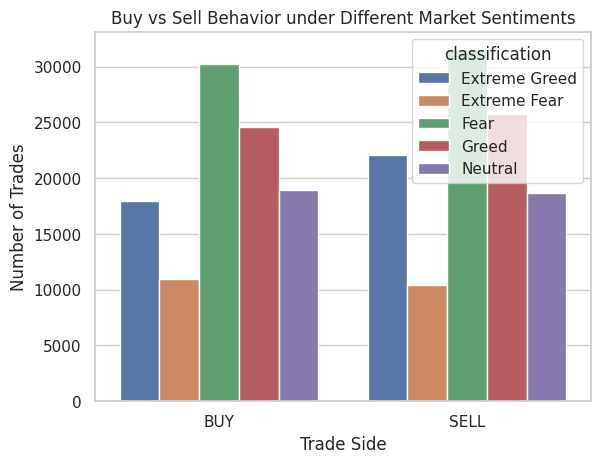

In [99]:
sns.countplot(x='Side', hue='classification', data=merged_data)

plt.title("Buy vs Sell Behavior under Different Market Sentiments")
plt.xlabel("Trade Side")
plt.ylabel("Number of Trades")
plt.show()

Total Profit by Sentiment

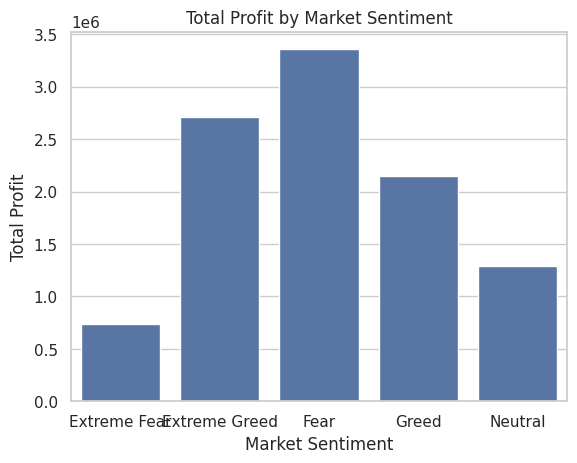

In [100]:
profit_sum = merged_data.groupby('classification')['Closed PnL'].sum().reset_index()

sns.barplot(x='classification', y='Closed PnL', data=profit_sum)

plt.title("Total Profit by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Total Profit")
plt.show()

Top Traders Chart

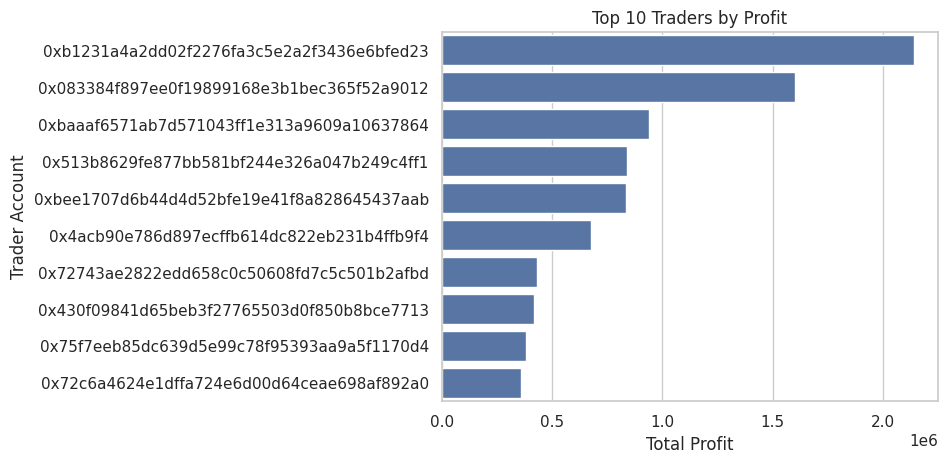

In [101]:
top_traders = merged_data.groupby('Account')['Closed PnL'].sum().nlargest(10).reset_index()

sns.barplot(x='Closed PnL', y='Account', data=top_traders)

plt.title("Top 10 Traders by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Trader Account")
plt.show()

Save Results

In [102]:
merged_data.to_csv("trader_sentiment_analysis.csv", index=False)

final notebook

1. Introduction
2. Dataset Loading
3. Data Cleaning
4. Data Merging
5. Data Analysis
6. Visualizations
7. Insights
8. Conclusion

Correlation Heatmap

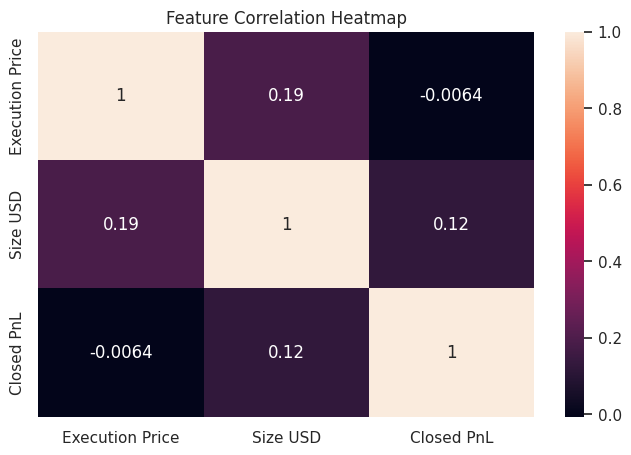

In [104]:
plt.figure(figsize=(8,5))
sns.heatmap(merged_data[['Execution Price','Size USD','Closed PnL']].corr(), annot=True)

plt.title("Feature Correlation Heatmap")
plt.show()

Profit Trend Over Time

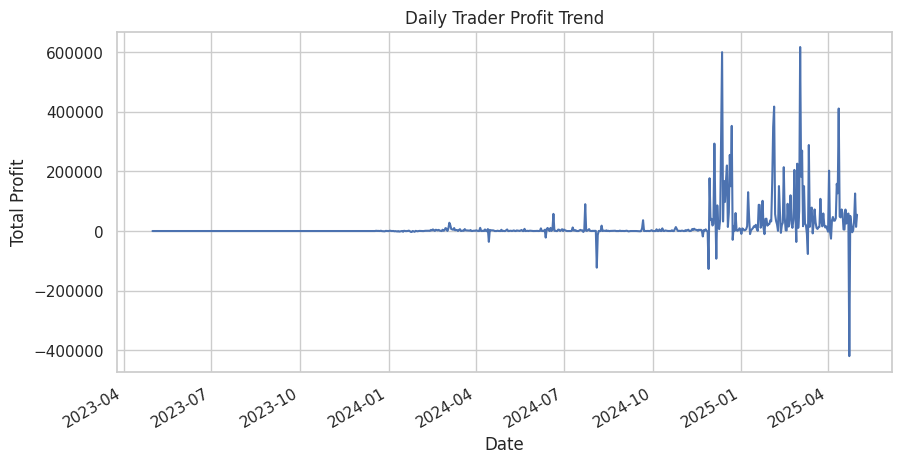

In [108]:
daily_profit = merged_data.groupby('Date')['Closed PnL'].sum()

plt.figure(figsize=(10,5))

daily_profit.plot()

plt.title("Daily Trader Profit Trend")
plt.xlabel("Date")
plt.ylabel("Total Profit")
plt.show()

Trade Size vs Profit

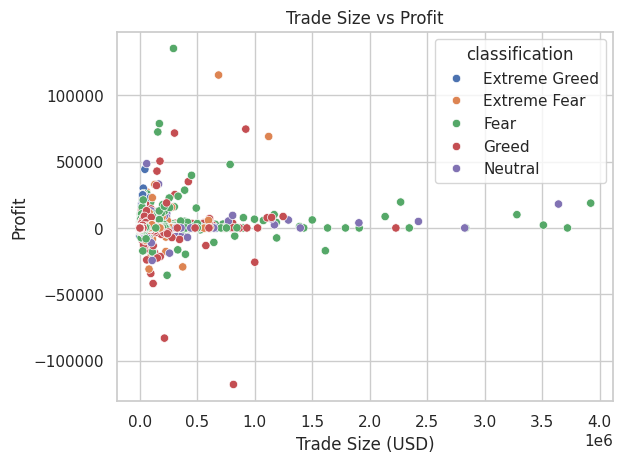

In [110]:
sns.scatterplot(
    x='Size USD',
    y='Closed PnL',
    hue='classification',
    data=merged_data
)

plt.title("Trade Size vs Profit")
plt.xlabel("Trade Size (USD)")
plt.ylabel("Profit")
plt.show()